# exp107gc_04 — ¿Despierta el gating con $\Gamma$ colapsado? (experimento [EXP-1] sobre la 107, $M = 4$)

**Hipótesis.** En `psbp_train.m`, $\Gamma_{hj}\mid\psi_{hj}$ y $\psi_{hj}\mid\Gamma_{hj}$ se alternan. Con $\psi\approx 0$
la verosimilitud de $\Gamma$ es plana, y con $\Gamma$ mal ubicado la condicional de $\psi$ lo empuja a 0. El gating
queda atrapado "dormido" aunque los datos lo sostengan. En la 107 el gating verdadero tiene TV 0.43 y vale
0.35 nats por observación en $\xi_1$, pero el PSBP ajustado tiene TV 0.01–0.05.

**Cambio [EXP-1]** (`psbp_train_colapsado.m`): $\Gamma_{hj}$ se muestrea con $\psi_{hj}$ **integrado**,

$$
\log p(T\mid\Gamma)=\tfrac{m^2}{2v}+\tfrac12\log v+\log\Phi\!\big(m/\sqrt v\big),\qquad
v=(\tau_\psi+D^\top D)^{-1},\ \ m=v(\tau_\psi\mu_\psi+D^\top T),
$$

y a continuación $\psi\mid\Gamma\sim\mathcal N^+(m,v)$. **[EXP-0]** vectoriza los pasos de $Z^*$ y de $S$ sin cambiar su
distribución (verificado en `test_equivalencia_vectorizacion.m`).

**Flujo.**
1. **Datos:** los de la 107, sin cambios, porque no hay `_01` nuevo.
2. **MATLAB:** `psbp_fd_iteracion_colapsado.m` lee el contrato de `escenario_107_1_r01_m04` y escribe las trazas en
   `experimento_107gc_1_r01_m04`. Mismos datasets, hiperparámetros, `mcmc_config` y semillas.
3. **Este notebook:** contrasta las dos variantes con la **misma** predictiva y las **mismas** métricas que el `107_04`.
   Sólo cubre el punto $M=4$: el experimento no reentrena el barrido.

## §1 Imports y `[CONFIG]`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_psbp_fd.utils.rutas import experiment_id, construir_paths
from model_psbp_fd.pipelines import (
    cargar_fpca, cargar_representacion, cargar_estandarizador, cargar_datasets_ar,
    cargar_hiperparametros, cargar_config_evaluacion, cargar_escenario,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PropagadorFuncional, ruta_traza, leer_traza, ModeloTraza
from model_psbp_fd.fit import intervalo_muestral, agrupar_momentos
from model_psbp_fd.fit.rolling import ventana_movil_funcional
from model_psbp_fd.fit.diagnostics_mcmc import tabla_diagnosticos, resumen_convergencia
from model_psbp_fd.fit.far_operador import FARp, seleccionar_kn
from model_psbp_fd.fit.intervalos import residuos_para_banda, banda_predictiva_modelo
import diagnostico_gating as dg

In [2]:
# -- [CONFIG] identificadores: DEBEN coincidir con psbp_fd_iteracion_colapsado.m
BASENAME_107 = "escenario_107"
BASENAME_GC  = "experimento_107gc"
ESCENARIO_ID = 1
REPLICA_ID   = 1
M_FPCA       = 4                    # el experimento reentrena SOLO este punto del barrido

# -- predictiva: los mismos valores que el 107_04 ---------------------------------
S_POR_ITER  = 1
S_FUNC      = 1000
BLOQUE_ORIG = 200
SEED_PRED   = 20260823
KN_MAX      = 12                    # tope de kn del FAR, como el 107_05

P107 = construir_paths(experiment_id(BASENAME_107, ESCENARIO_ID, REPLICA_ID, M_FPCA), crear=False)
PGC  = construir_paths(experiment_id(BASENAME_GC,  ESCENARIO_ID, REPLICA_ID, M_FPCA))
# Las trazas de cada variante; datos, FPCA y contrato son SIEMPRE los de la 107.
VARIANTES = {"107_original": P107["out_artefact"], "107_gamma_colapsado": PGC["out_artefact"]}
for v, d in VARIANTES.items():
    print(f"{v:<22} trazas en {d}")

107_original           trazas en /home/user/bayesian_non_parametrics/artefact/simulaciones/escenario_107_1_r01_m04
107_gamma_colapsado    trazas en /home/user/bayesian_non_parametrics/artefact/simulaciones/experimento_107gc_1_r01_m04


## §2 Artefactos de la 107 (sólo lectura)

In [3]:
EVAL = cargar_config_evaluacion(P107)
HP   = cargar_hiperparametros(P107)
fpca = cargar_fpca(P107)
std  = cargar_estandarizador(P107, DataStandardizer)
fr, THETA, _ = cargar_representacion(P107)
dfs_train, man = cargar_datasets_ar(P107, "train")
dfs_test, _    = cargar_datasets_ar(P107, "test")
ESC  = cargar_escenario(str(P107["raw"] / f"escenario_{ESCENARIO_ID}.npz"))

grilla = ESC["grilla"]
X_suav = fr.reconstruct(THETA)                          # objetivo: curva suavizada
T0, N_LAGS = int(EVAL["T0"]), int(EVAL["n_lags"])
NIVEL, MODO_RESIDUO, OBJETIVO = float(EVAL["nivel_credibilidad"]), EVAL["modo_residuo"], EVAL["objetivo_evaluacion"]
assert OBJETIVO == "curva_suavizada" and MODO_RESIDUO == "ninguno"
ci = list(man["component_idx"])
n_comp, n_iter = len(ci), int(HP["n_iter"])
dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True) for k in range(n_comp)}
n_orig = len(dfs_full[0])
es_train = np.arange(n_orig) < len(dfs_train[0])
t_orig = np.arange(N_LAGS, N_LAGS + n_orig)            # base-0
X_OBJ = X_suav[t_orig]
print(f"M={fpca.M}  K={fpca.K}  T0={T0}  N_LAGS={N_LAGS}  origenes={n_orig} (train {es_train.sum()})  "
      f"cadenas={n_iter}  covariables={list(dfs_train[0].columns[1:])}")

M=4  K=14  T0=700  N_LAGS=2  origenes=998 (train 698)  cadenas=2  covariables=['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2']


## §3 Trazas de las dos variantes

In [4]:
MC, TRZ = {}, {}
for v, dir_trazas in VARIANTES.items():
    Pv = dict(P107); Pv["trazas"] = dir_trazas          # ruta_traza lee de 'trazas' si existe
    MC[v] = {k: {} for k in range(n_comp)}
    TRZ[v] = {k: {} for k in range(n_comp)}
    for k in range(n_comp):
        esperado = list(dfs_train[k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(Pv, ci[k] + 1, c + 1))
            assert feat == esperado, (v, k, c, feat, esperado)
            MC[v][k][c] = ModeloTraza(traces, burn, feat)
            TRZ[v][k][c] = (traces, burn)
    print(f"{v:<22} OK: {n_comp} componentes x {n_iter} cadenas · burn={burn}")
BURN = burn

107_original           OK: 4 componentes x 2 cadenas · burn=1000


107_gamma_colapsado    OK: 4 componentes x 2 cadenas · burn=1000


## §4 Diagnóstico del gating (el objetivo del experimento)

Cifras por componente y cadena, definidas en `diagnostico_gating.py` e invariantes a la etiqueta.
**TV** es la variación total de los pesos con el estado: 0 significa gating dormido. Como referencia, en la 107 el
gating **verdadero** tiene TV 0.43 y vale 0.35 / 0.13 / 0.06 / 0.03 nats por observación en $\xi_1..\xi_4$.

In [5]:
filas = []
for v in VARIANTES:
    for k in range(n_comp):
        X_k = dfs_train[k].iloc[:, 1:].to_numpy()
        mup = HP["hyperparams_list"][k]["hyperparams"]["mupsij"]
        for c in range(n_iter):
            traces, burn = TRZ[v][k][c]
            filas.append({"variante": v, "fpc": ci[k] + 1, "cadena": c + 1,
                          **dg.diagnostico_gating(traces, burn, X_k, mup)})
GATING = pd.DataFrame(filas)
GATING.to_csv(PGC["out_report"] / "x01_diagnostico_gating.csv", index=False)
(GATING.pivot_table(index="fpc", columns=["variante", "cadena"], values=["TV", "sd_eta"])
       .round(3))

TV                                         sd_eta  \
variante 107_gamma_colapsado        107_original        107_gamma_colapsado   
cadena                     1      2            1      2                   1   
fpc                                                                           
1                      0.038  0.006        0.012  0.046               0.061   
2                      0.030  0.032        0.018  0.014               0.064   
3                      0.099  0.016        0.024  0.044               0.110   
4                      0.047  0.017        0.059  0.106               0.076   

                                     
variante        107_original         
cadena        2            1      2  
fpc                                  
1         0.093        0.085  0.080  
2         0.067        0.064  0.078  
3         0.021        0.035  0.066  
4         0.021        0.067  0.118

In [6]:
GATING.groupby(["variante", "fpc"])[["TV", "sd_eta", "gamma_on", "psi_rel", "n_atomos"]].mean().round(3)

TV  sd_eta  gamma_on  psi_rel  n_atomos
variante            fpc                                            
107_gamma_colapsado 1    0.022   0.077     0.124    0.370       2.5
                    2    0.031   0.065     0.101    0.437       3.0
                    3    0.058   0.066     0.074    0.351       4.0
                    4    0.032   0.049     0.095    0.335       4.0
107_original        1    0.029   0.083     0.126    0.367       2.5
                    2    0.016   0.071     0.111    0.373       1.5
                    3    0.034   0.050     0.085    0.352       3.5
                    4    0.083   0.093     0.114    0.333       4.5

## §5 Convergencia (misma tabla que el `_03`)

In [7]:
CONV = {}
for v in VARIANTES:
    tabla = tabla_diagnosticos(MC[v], BURN, component_idx=ci, claves=("betajhout", "pijout"))
    CONV[v] = resumen_convergencia(tabla)
    tabla.to_csv(PGC["out_report"] / f"x02_convergencia_{v}.csv", index=False)
pd.DataFrame({v: {k: r[k] for k in ("n_variables", "rhat_max", "ess_min", "geweke_max", "n_no_converge", "todo_converge")}
              for v, r in CONV.items()}).T

,n_variables,rhat_max,ess_min,geweke_max,n_no_converge,todo_converge
107_original,64,1.589357,6.70101,12.634726,26,False
107_gamma_colapsado,64,1.635509,8.459055,8.704147,24,False


## §6 Predicción a $h=1$: el mismo camino que el `107_04`

In [8]:
PRED = {}
for v in VARIANTES:
    S_POR_CADENA = MC[v][0][0].traces["alphahout"].shape[0] - BURN
    SC = np.empty((S_POR_CADENA * n_iter, n_orig, n_comp), dtype=np.float32)
    for k in range(n_comp):
        for c in range(n_iter):
            m = MC[v][k][c].muestrear(dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * ci[k] + c)
            SC[c * S_POR_CADENA:(c + 1) * S_POR_CADENA, :, k] = m
    paso = max(1, SC.shape[0] // S_FUNC)
    prop = PropagadorFuncional(fpca.Psi_grid, fpca.mu_grid, estandarizador=std, modo_residuo=MODO_RESIDUO)
    Xp, li, ls = (np.empty((n_orig, grilla.size)) for _ in range(3))
    for i0 in range(0, n_orig, BLOQUE_ORIG):
        sl = slice(i0, i0 + BLOQUE_ORIG)
        Xd = prop.curvas_desde_scores(SC[::paso, sl], seed=SEED_PRED)
        Xp[sl] = Xd.mean(axis=0)
        li[sl] = np.quantile(Xd, (1 - NIVEL) / 2, axis=0)
        ls[sl] = np.quantile(Xd, 1 - (1 - NIVEL) / 2, axis=0)
    PRED[v] = (Xp, li, ls)
    print(f"{v:<22} {SC.shape[0]} extracciones por score · {SC[::paso].shape[0]} funcionales")

# control: la variante original recalculada debe coincidir con la banda del 107_04
z = np.load(P107["predict"] / "banda_funcional_psbp.npz", allow_pickle=False)
assert np.array_equal(z["t_orig"], t_orig + 1)
d_rel = np.abs(PRED["107_original"][0] - z["X_pred"]).mean() / np.abs(z["X_pred"]).mean()
print(f"107_original recalculado vs 107_04: diferencia relativa media de X_pred = {d_rel:.2e}")

# -- FAR(p) de referencia, como el 107_05 ------------------------------------------
L_GRAM = np.linalg.cholesky(fpca.W)
THETA_W = THETA @ L_GRAM
cv = seleccionar_kn(THETA_W[:T0], kn_max=min(KN_MAX, THETA_W.shape[1]), pesos="conteo", p=N_LAGS)
far = FARp(p=N_LAGS, kn=cv.kn_L2, pesos="conteo").fit(THETA_W[:T0])
X_far = fr.reconstruct(np.linalg.solve(L_GRAM.T, far.predict_serie(THETA_W).T).T)
li_far, ls_far = banda_predictiva_modelo(X_far, residuos_para_banda(X_OBJ, X_far, es_train), nivel=NIVEL)
PRED["far"] = (X_far, li_far, ls_far)

107_original           4000 extracciones por score · 1000 funcionales


107_gamma_colapsado    4000 extracciones por score · 1000 funcionales


107_original recalculado vs 107_04: diferencia relativa media de X_pred = 2.16e-08


## §7 Las diez métricas sobre la ventana móvil

In [9]:
VM = EVAL["ventana_movil"]
VENTANAS_W = VM["w"]
W_REF = VENTANAS_W[len(VENTANAS_W) // 2]
METRICAS_A, METRICAS_B = EVAL["metricas_bloque_A"], EVAL["metricas_bloque_B"]

TABLAS = {}
for nombre, (Xp, li, ls) in PRED.items():
    for w in VENTANAS_W:
        tb = ventana_movil_funcional(X_OBJ, Xp, grilla, int(es_train.sum()), w=w, paso=VM["paso"],
                                     solapadas=VM["solapadas"], t_offset=N_LAGS,
                                     li=li, ls=ls, nivel=NIVEL, bloque_A=True)
        tb["modelo"], tb["w"] = nombre, w
        TABLAS[(nombre, w)] = tb
VMT = pd.concat(TABLAS.values(), ignore_index=True)
VMT = VMT[~VMT["cruza_T0"]]
assert (VMT["mae_f"] <= VMT["l2_medio"] + 1e-12).all()
assert (VMT["l2_medio"] <= VMT["linf_medio"] + 1e-12).all()
assert (VMT["linf_medio"] <= VMT["linf_max"] + 1e-12).all()
assert (VMT["picp_simultaneo"] <= VMT["picp"] + 1e-12).all()
assert (VMT["winkler"] <= VMT["winkler_max_medio"] + 1e-12).all()
assert (VMT["winkler_max_medio"] <= VMT["winkler_max_glob"] + 1e-12).all()
cols = METRICAS_A + METRICAS_B
VMT[VMT.w == W_REF].groupby(["bloque", "modelo"])[cols].mean().round(4)

mae_f  rmse_f  linf_medio  linf_max    mpiw  \
bloque modelo                                                              
test   107_gamma_colapsado  0.7110  0.8912      1.6694    3.0421  3.3220   
       107_original         0.7084  0.8880      1.6632    3.0274  3.3265   
       far                  0.7073  0.8864      1.6583    2.9830  3.3194   
train  107_gamma_colapsado  0.6831  0.8597      1.6174    2.8337  3.3101   
       107_original         0.6823  0.8587      1.6155    2.8350  3.3072   
       far                  0.6727  0.8485      1.5957    2.7859  3.3194   

                              picp  picp_simultaneo  winkler  \
bloque modelo                                                  
test   107_gamma_colapsado  0.9345           0.5065   4.2654   
       107_original         0.9351           0.5027   4.2645   
       far                  0.9371           0.5476   4.2291   
train  107_gamma_colapsado  0.9412           0.5169   4.0493   
       107_original         0.9408           0.5219   4.0641   
       far                  0.9471           0.5848   3.9922   

                            winkler_max_medio  winkler_max_glob  
bloque modelo                                                    
test   107_gamma_colapsado            12.7966           54.8545  
       107_original                   12.7855           53.7612  
       far                            12.0166           55.2856  
train  107_gamma_colapsado            11.2334           49.8551  
       107_original                   11.2415           49.9255  
       far                            10.1188           47.3071

### §7.1 Quién gana cada ventana de test (`w = W_REF`): Γ colapsado contra la 107 original y contra el FAR

In [10]:
def ganancias(a_nom, b_nom, w=W_REF):
    sel = lambda m: VMT[(VMT.w == w) & (VMT.bloque == "test") & (VMT.modelo == m)].set_index("t_centro")
    a, b = sel(a_nom), sel(b_nom)
    fila = {"contra": b_nom}
    for m in METRICAS_A + ["winkler", "winkler_max_medio", "winkler_max_glob"]:
        fila[m] = float((a[m] < b[m]).mean())
    for m in ("picp", "picp_simultaneo"):
        fila[m] = float(((a[m] - NIVEL).abs() < (b[m] - NIVEL).abs()).mean())
    return fila
pd.DataFrame([ganancias("107_gamma_colapsado", r) for r in ("107_original", "far")]).set_index("contra").round(3)

,mae_f,rmse_f,linf_medio,linf_max,winkler,winkler_max_medio,winkler_max_glob,picp,picp_simultaneo
contra,,,,,,,,,
107_original,0.14,0.166,0.188,0.332,0.458,0.472,0.325,0.483,0.339
far,0.45,0.410,0.373,0.321,0.450,0.262,0.513,0.336,0.188


### §7.2 Resumen mín / máx / promedio en test (`w = W_REF`)

In [11]:
RESUMEN = (VMT[(VMT.w == W_REF) & (VMT.bloque == "test")]
           .groupby("modelo")[cols].agg(["min", "max", "mean"]).T.round(4))
RESUMEN.to_csv(PGC["out_report"] / "x03_resumen_test.csv")
RESUMEN

modelo                  107_gamma_colapsado  107_original      far
mae_f             min                0.6069        0.6100   0.6156
                  max                0.7843        0.7819   0.7944
                  mean               0.7110        0.7084   0.7073
rmse_f            min                0.7549        0.7535   0.7608
                  max                0.9845        0.9844   1.0115
                  mean               0.8912        0.8880   0.8864
linf_medio        min                1.4123        1.4202   1.4507
                  max                1.8619        1.8567   1.8734
                  mean               1.6694        1.6632   1.6583
linf_max          min                2.0866        2.0650   2.2105
                  max                3.7237        3.6631   3.5756
                  mean               3.0421        3.0274   2.9830
mpiw              min                3.2250        3.2320   3.3194
                  max                3.4845        3.4658   3.3194
                  mean               3.3220        3.3265   3.3194
picp              min                0.8996        0.9053   0.8902
                  max                0.9604        0.9658   0.9662
                  mean               0.9345        0.9351   0.9371
picp_simultaneo   min                0.3333        0.3333   0.3000
                  max                0.7000        0.6667   0.7333
                  mean               0.5065        0.5027   0.5476
winkler           min                3.6295        3.6562   3.5691
                  max                5.1074        5.1468   5.2133
                  mean               4.2654        4.2645   4.2291
winkler_max_medio min                8.1244        8.1372   7.3693
                  max               18.1205       17.7924  18.6592
                  mean              12.7966       12.7855  12.0166
winkler_max_glob  min               24.9641       24.5410  23.0808
                  max               80.0255       78.7643  78.0093
                  mean              54.8545       53.7612  55.2856

## §8 Figuras

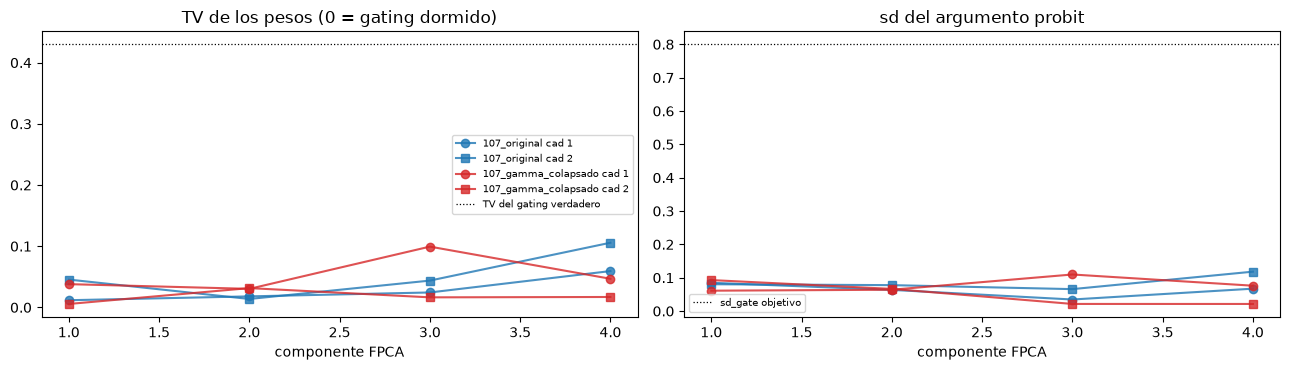

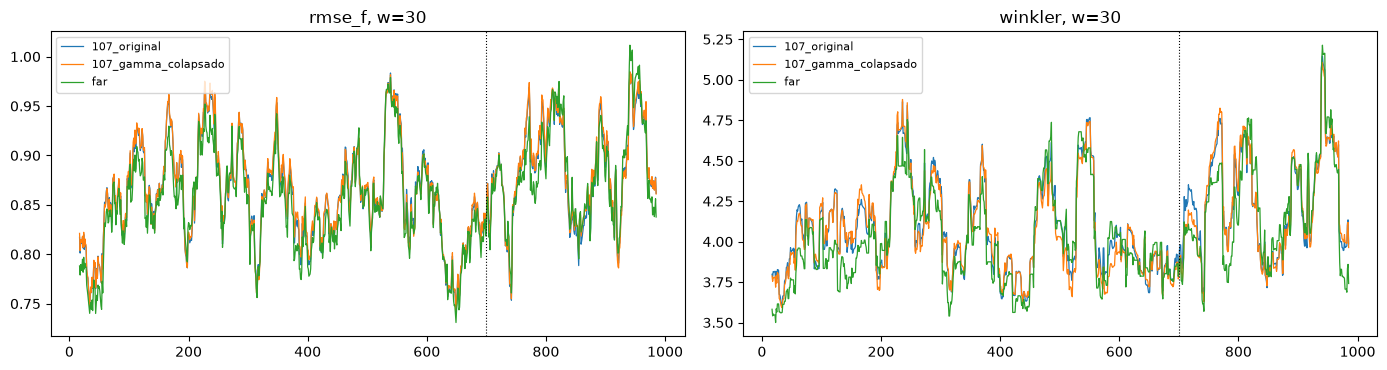

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for v, col in zip(VARIANTES, ("C0", "C3")):
    g = GATING[GATING.variante == v]
    for c, mk in zip(range(1, n_iter + 1), ("o", "s")):
        gg = g[g.cadena == c]
        ax[0].plot(gg.fpc, gg.TV, mk + "-", color=col, alpha=.8, label=f"{v} cad {c}")
        ax[1].plot(gg.fpc, gg.sd_eta, mk + "-", color=col, alpha=.8)
ax[0].axhline(0.43, color="k", ls=":", lw=.9, label="TV del gating verdadero")
ax[1].axhline(0.8, color="k", ls=":", lw=.9, label="sd_gate objetivo")
ax[0].set_title("TV de los pesos (0 = gating dormido)"); ax[1].set_title("sd del argumento probit")
for a in ax:
    a.set_xlabel("componente FPCA"); a.legend(fontsize=7)
fig.tight_layout(); fig.savefig(PGC["out_report"] / "x04_gating.png", dpi=120)

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
for nombre in PRED:
    tb = TABLAS[(nombre, W_REF)]
    ax[0].plot(tb["t_centro"], tb["rmse_f"], lw=.9, label=nombre)
    ax[1].plot(tb["t_centro"], tb["winkler"], lw=.9, label=nombre)
for a, t in zip(ax, ("rmse_f", "winkler")):
    a.axvline(T0, color="k", ls=":", lw=.8); a.set_title(f"{t}, w={W_REF}"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(PGC["out_report"] / "x05_ventana_movil.png", dpi=120)